# HOMEWORK 2

In [30]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 5]

### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

In [31]:
def get_white_patched(col, row, img):
    white = img[row, col, :]
    coeffs = 255.0/white

    # Apply white balancing and generate balanced image
    balanced = np.zeros_like(img, dtype=np.float32)
    for channel in range(3):
        balanced[..., channel] = img[..., channel] * coeffs[channel]

    # White patching does not guarantee that the dynamic range is preserved, images must be clipped.
    balanced = balanced/255
    balanced[balanced > 1] = 1

    return balanced

(<Axes: >, <matplotlib.image.AxesImage object at 0x7f3fa7122e90>)

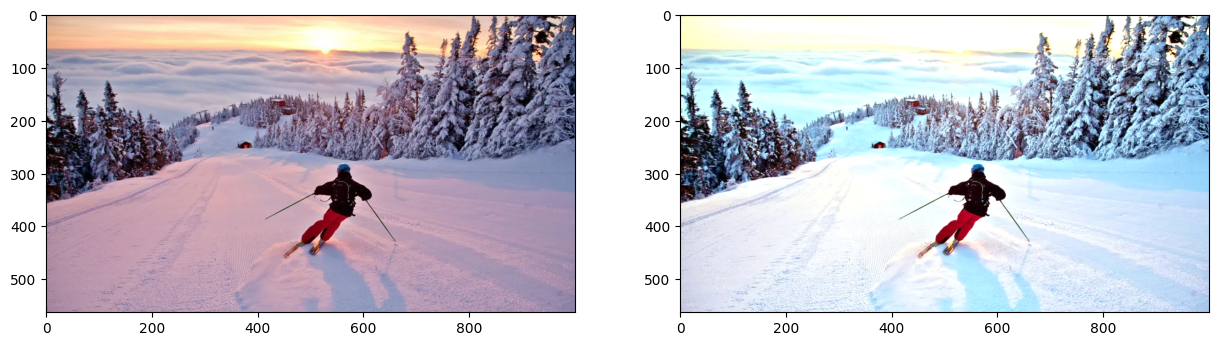

In [32]:
ski = plt.imread('data/evening-ski.webp')

plt.subplot(121), plt.imshow(ski)
plt.subplot(122), plt.imshow(get_white_patched(324, 368, ski))

(<Axes: >, <matplotlib.image.AxesImage object at 0x7f3fb1c4e210>)

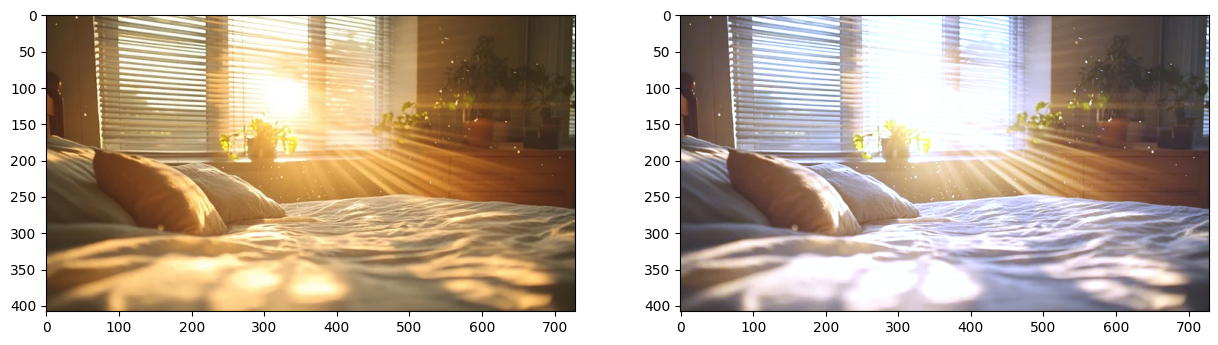

In [33]:
bed = plt.imread('data/bedroom.webp')

plt.subplot(121), plt.imshow(bed)
plt.subplot(122), plt.imshow(get_white_patched(649, 355, bed))

(<Axes: >, <matplotlib.image.AxesImage object at 0x7f3fa7e1ad50>)

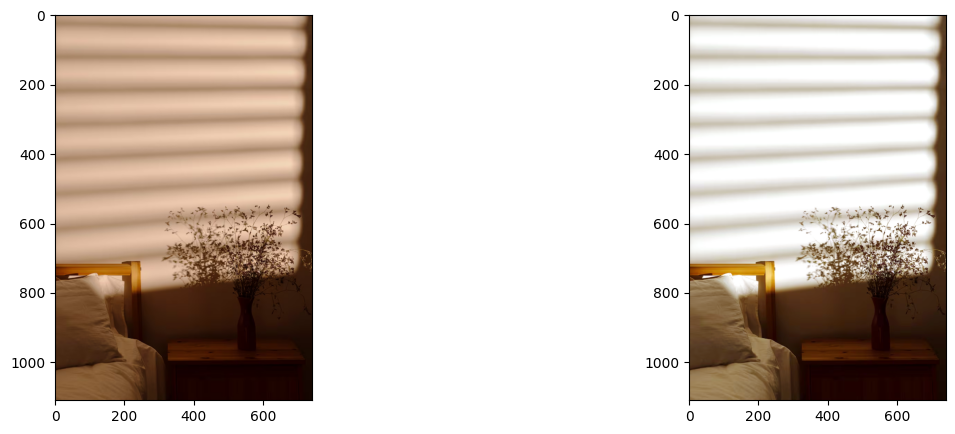

In [35]:
wall = plt.imread('data/wall.avif')

plt.subplot(121), plt.imshow(wall)
plt.subplot(122), plt.imshow(get_white_patched(17, 164, wall))

### Gray world
This algorithm assumes that a scene, on average, is gray.

In [67]:
def get_gray_world(fixed, img):
    split = cv2.split(img)

    # Compute the mean values for all three colour channels (red, green, blue)
    means = np.array([np.mean(split[ch]) for ch in range(3)])

    # Compute the coefficients kr, kg, kb
    coeffs = means[fixed] / means

    # Apply color balancing and generate the balanced image
    balanced = np.zeros_like(img, dtype=np.float32)
    for channel in range(3):
        balanced[..., channel] = img[..., channel] * coeffs[channel]

    balanced = balanced/255
    balanced[balanced > 1] = 1

    return balanced

(<Axes: >, <matplotlib.image.AxesImage object at 0x7f3f9ed12350>)

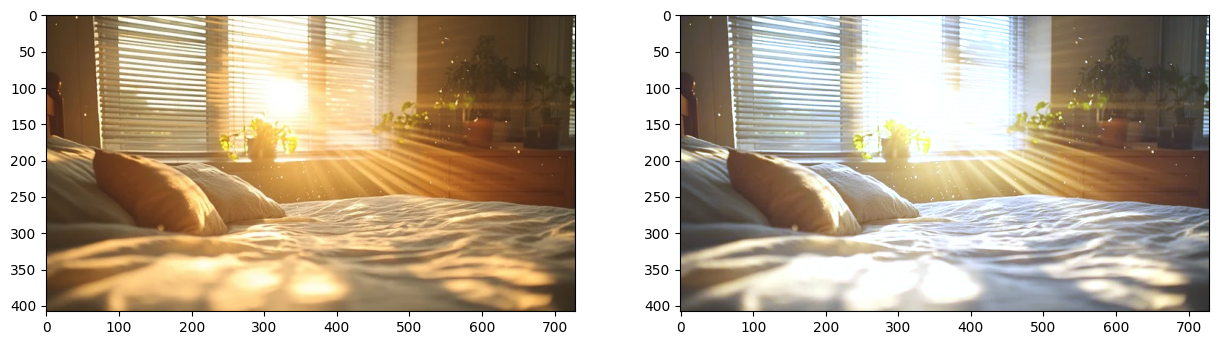

In [68]:
forest = plt.imread('data/bedroom.webp')

plt.subplot(121), plt.imshow(forest)
plt.subplot(122), plt.imshow(get_gray_world(0, forest))

(<Axes: >, <matplotlib.image.AxesImage object at 0x7f3f9849d810>)

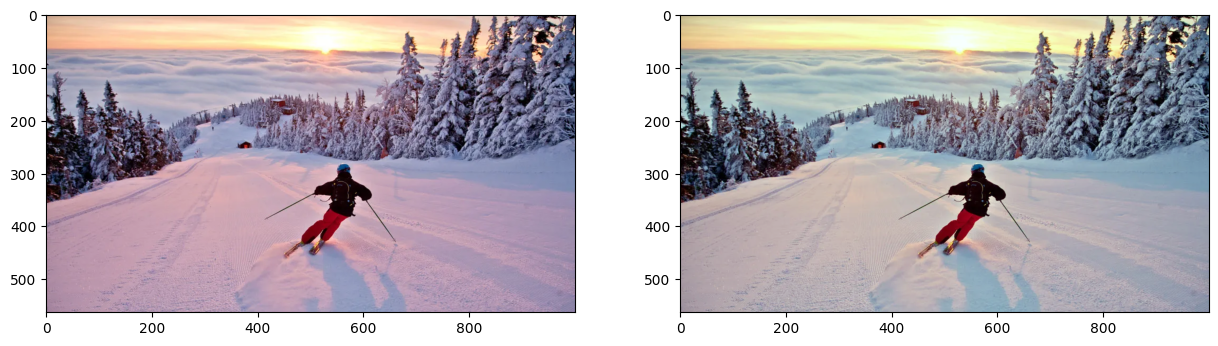

In [75]:
ski = plt.imread('data/evening-ski.webp')

plt.subplot(121), plt.imshow(ski)
plt.subplot(122), plt.imshow(get_gray_world(2, ski))

### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

In [ ]:
# Load your image
img = cv2.imread('...')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the maximum values for all three colour channels (red, green, blue)
max_r = 
max_g = 
max_b = 

# Apply scale-by-max balancing and generate the balanced image
balanced =

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)